In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [7]:
data = pd.read_csv('top_movies.csv')

In [12]:
data['Year'].value_counts()

Year
2013    239
2011    231
2014    231
2006    230
2007    218
       ... 
1923      1
1930      1
1920      1
1922      1
1915      1
Name: count, Length: 107, dtype: int64

In [4]:
#split the genres column into a list of genres
data['Genres'] = data['Genres'].str.split(',')
data = data.explode('Genres')
data = data[~(data['Genres'].isin(['\\N', 'Film-Noir']))]
data = data[data['Year'] > 1920]

In [5]:
data['Rating'].mean()

np.float64(6.645880053492439)

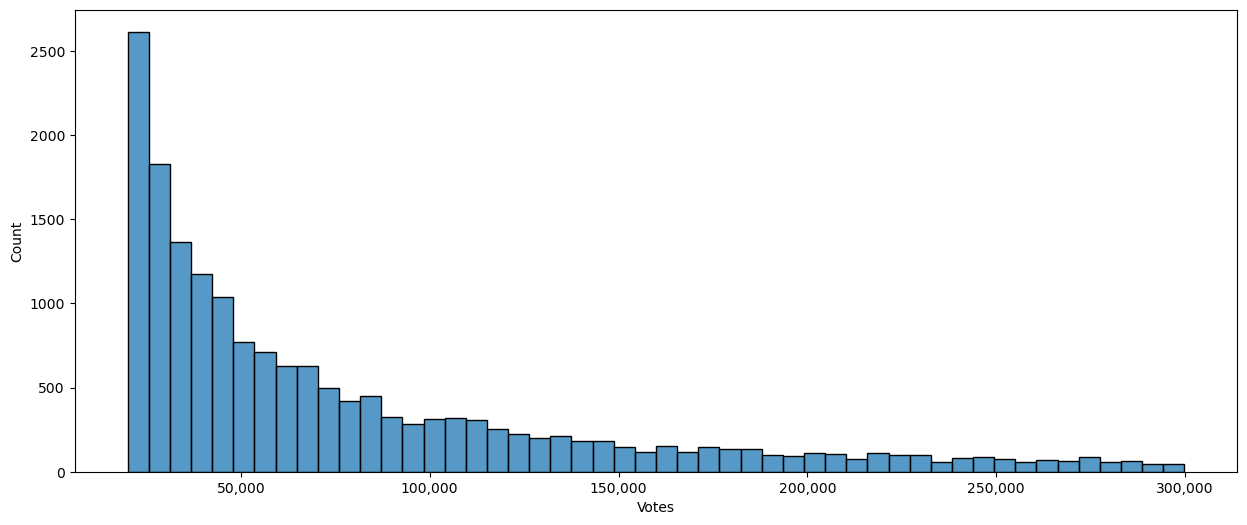

In [5]:
plt.figure(figsize=(15,6))
sns.histplot(data[data['Votes'] < 300000]['Votes'], bins=50, kde=False)
ax = plt.gca()

# Format with commas (e.g., 1,000,000)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

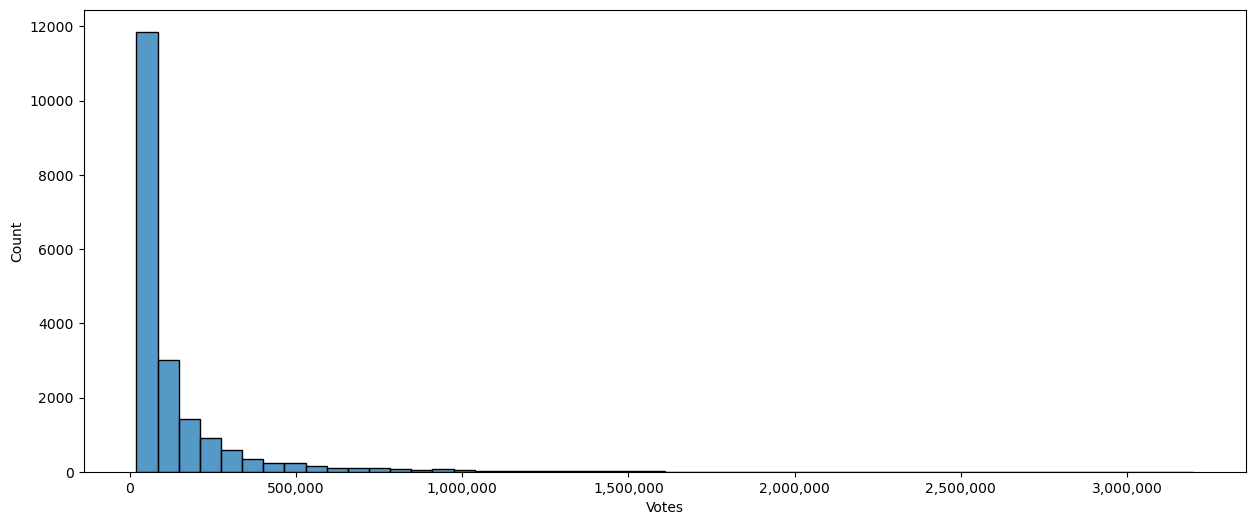

In [6]:
plt.figure(figsize=(15,6))
sns.histplot(data['Votes'], bins=50, kde=False)
ax = plt.gca()

# Format with commas (e.g., 1,000,000)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [20]:
C = data['Rating'].mean()

m = data['Votes'].quantile(0.90)

data['score'] = (
    (data['Rating'] * data['Votes'] + m * C)
    / (data['Votes'] + m)
).round(2)

In [8]:
data

,Title,Year,Genres,Rating,Votes,score
0,The Shawshank Redemption,1994,Drama,9.3,3199370,9.07
1,The Godfather,1972,Crime,9.2,2232183,8.90
1,The Godfather,1972,Drama,9.2,2232183,8.90
2,The Chaos Class,1975,Comedy,9.1,46358,6.97
3,The Dark Knight,2008,Crime,9.1,3180142,8.89
...,...,...,...,...,...,...
7418,Sadak 2,2020,Action,1.2,97207,5.32
7418,Sadak 2,2020,Drama,1.2,97207,5.32
7419,Reis,2017,Biography,1.0,74715,5.53
7419,Reis,2017,Drama,1.0,74715,5.53


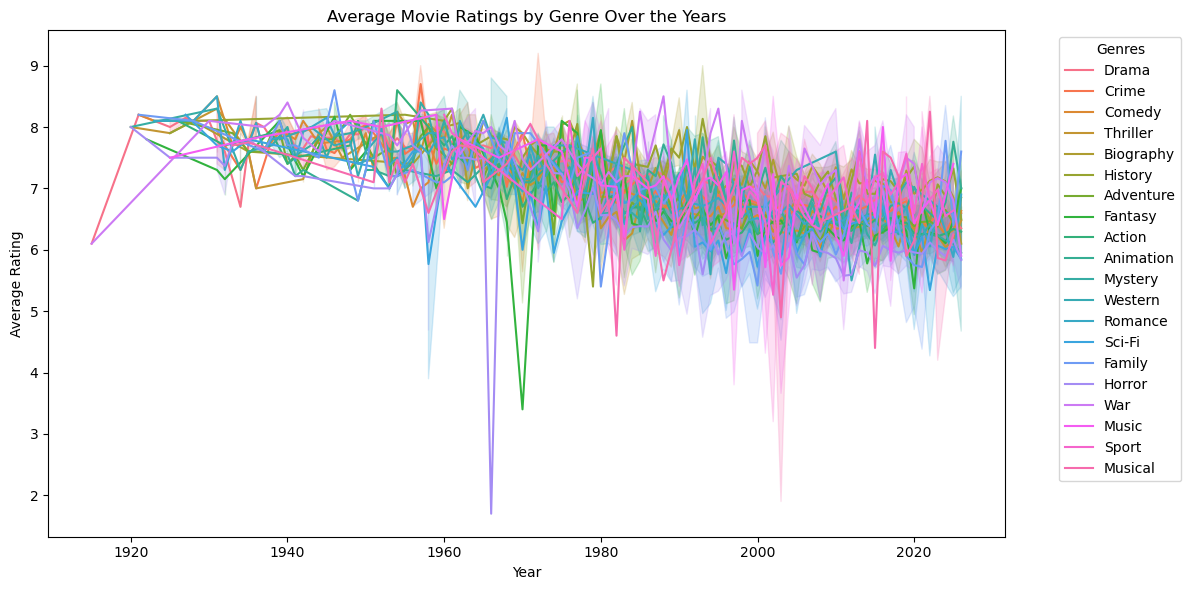

In [9]:
#line chart for generes over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Year', y='Rating', hue='Genres', marker=None)
plt.title('Average Movie Ratings by Genre Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
data

,Title,Year,Genres,Rating,Votes,score
0,The Shawshank Redemption,1994,Drama,9.3,3199370,9.07
1,The Godfather,1972,Crime,9.2,2232183,8.90
1,The Godfather,1972,Drama,9.2,2232183,8.90
2,The Chaos Class,1975,Comedy,9.1,46358,6.97
3,The Dark Knight,2008,Crime,9.1,3180142,8.89
...,...,...,...,...,...,...
7418,Sadak 2,2020,Action,1.2,97207,5.32
7418,Sadak 2,2020,Drama,1.2,97207,5.32
7419,Reis,2017,Biography,1.0,74715,5.53
7419,Reis,2017,Drama,1.0,74715,5.53


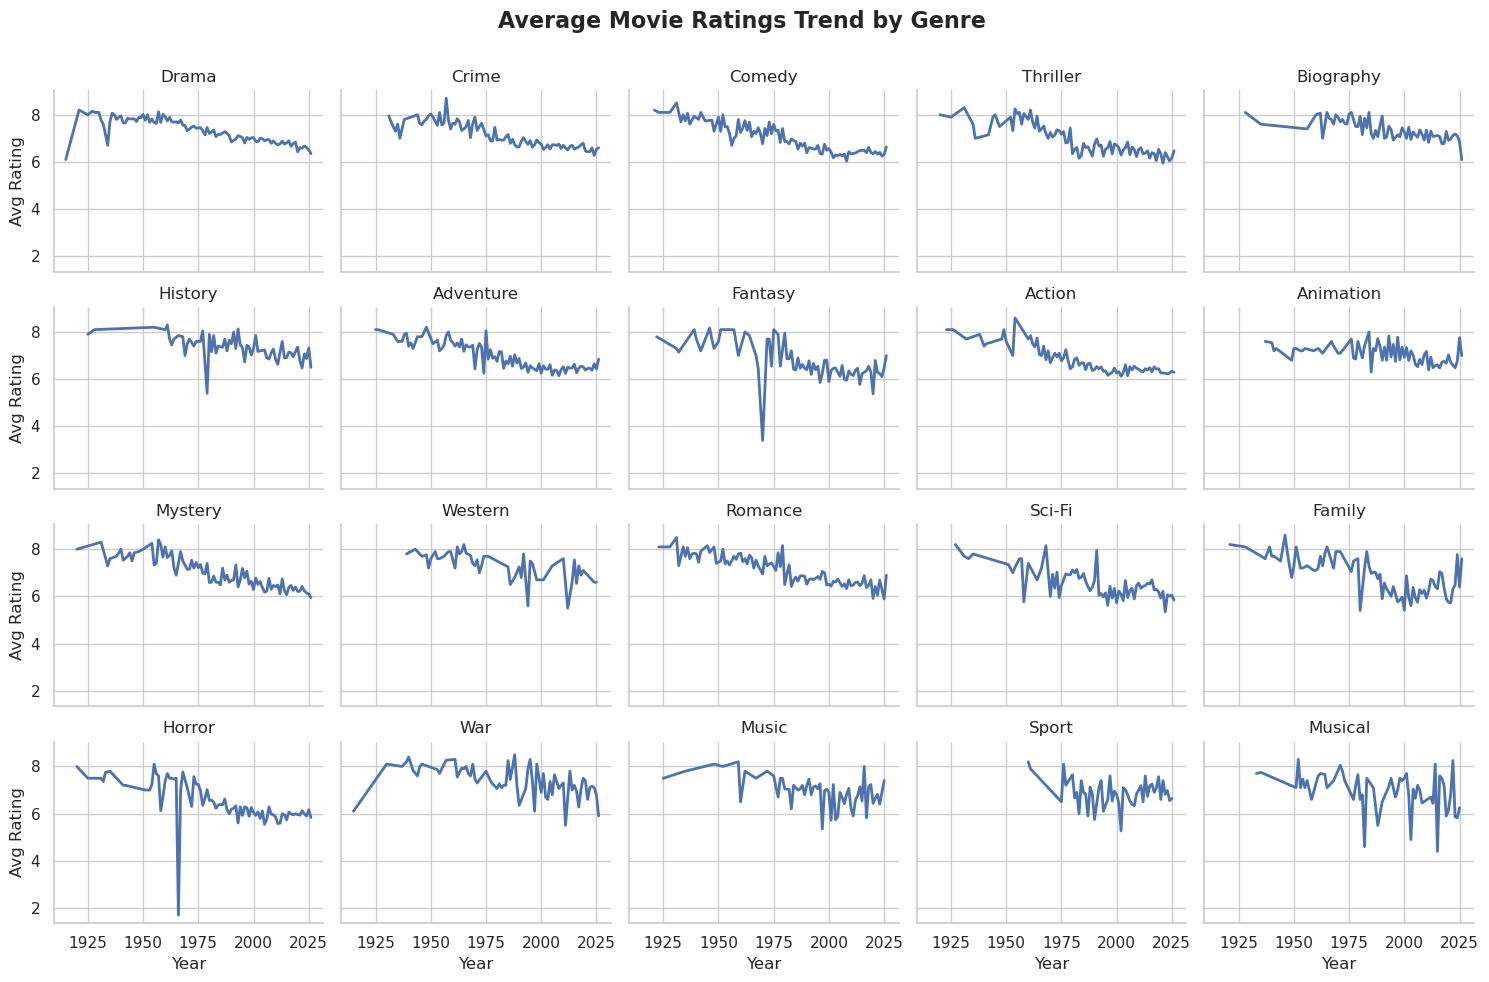

In [11]:
sns.set_theme(style="whitegrid")

# 3. Create a faceted line plot (Small Multiples)
g = sns.relplot(
    data=data,
    x="Year",
    y="Rating",
    col="Genres",  # This splits the data into subplots by genre
    col_wrap=5,  # Sets 5 subplots per row
    kind="line",
    errorbar=None,  # Removes the overlapping shaded areas for a cleaner look
    height=2.5,  # Height of each individual subplot
    aspect=1.2,  # Aspect ratio of each subplot
    linewidth=2,
)

g.set_titles("{col_name}")  # Clean subplot titles (just the Genre name)
g.set_axis_labels("Year", "Avg Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Average Movie Ratings Trend by Genre", fontsize=16, weight="bold")

plt.show()

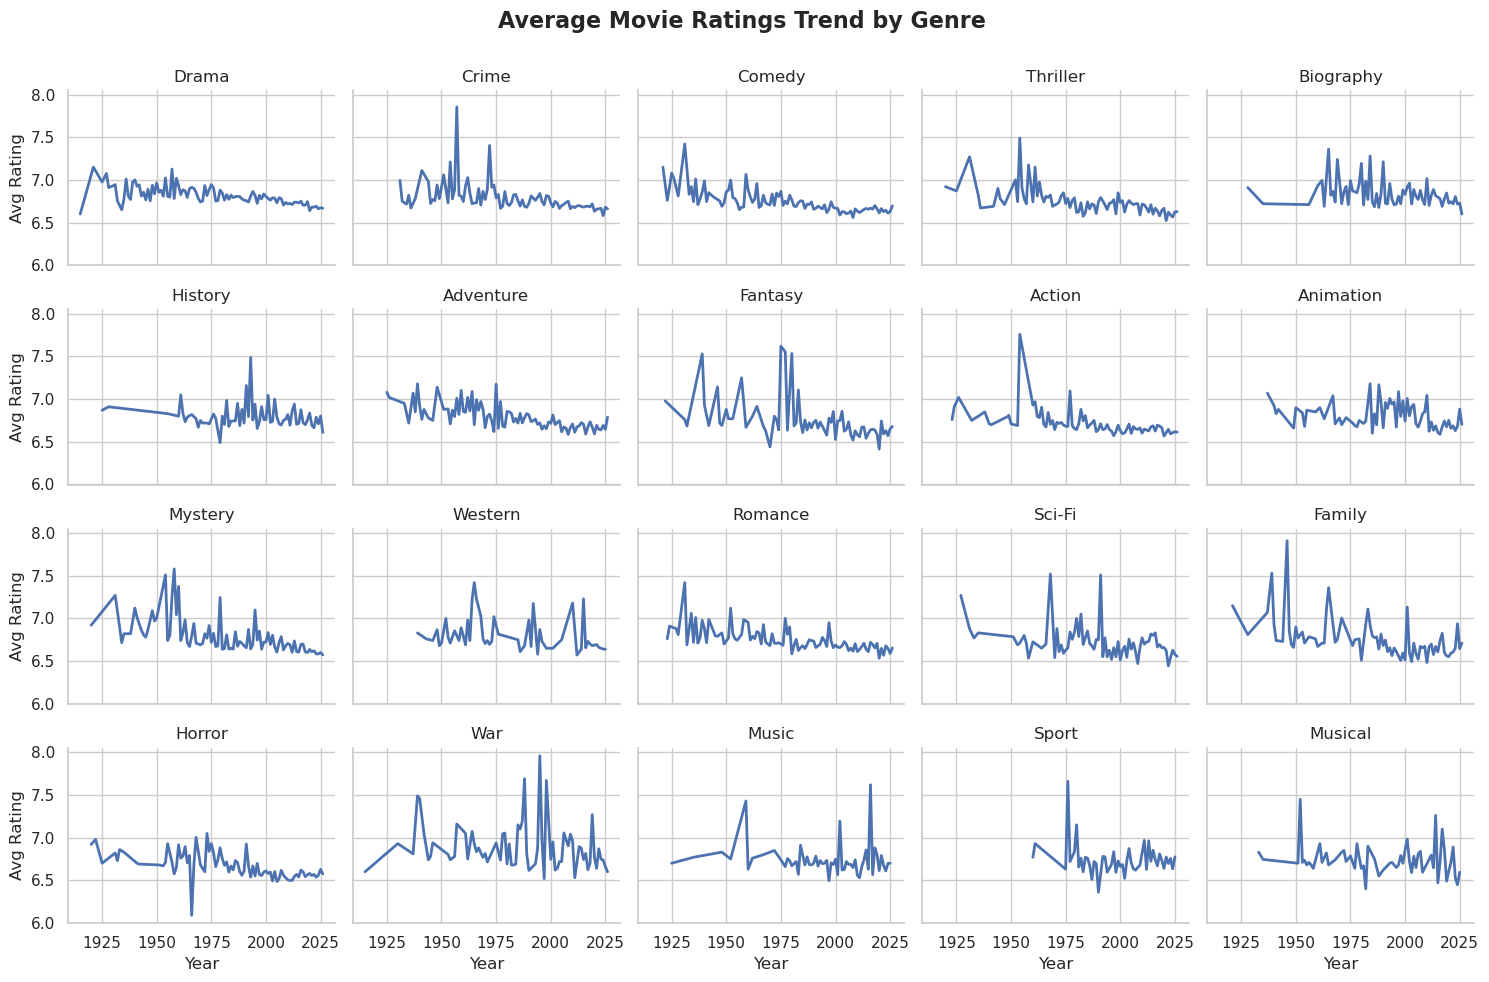

In [12]:
sns.set_theme(style="whitegrid")

# 3. Create a faceted line plot (Small Multiples)
g = sns.relplot(
    data=data,
    x="Year",
    y="score",
    col="Genres",  # This splits the data into subplots by genre
    col_wrap=5,  # Sets 5 subplots per row
    kind="line",
    errorbar=None,  # Removes the overlapping shaded areas for a cleaner look
    height=2.5,  # Height of each individual subplot
    aspect=1.2,  # Aspect ratio of each subplot
    linewidth=2,
)

g.set_titles("{col_name}")  # Clean subplot titles (just the Genre name)
g.set_axis_labels("Year", "Avg Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Average Movie Ratings Trend by Genre", fontsize=16, weight="bold")

plt.show()

In [13]:
data = data.sort_values(['Genres', 'Year'])
data['smoothed_score'] = data.groupby('Genres')['score'].transform(lambda x: x.rolling(window=5, min_periods=1).mean()).round(2)

In [21]:
data

,Title,Year,Genres,Rating,Votes,score
0,The Shawshank Redemption,1994,Drama,9.3,3199370,9.07
1,The Godfather,1972,"Crime,Drama",9.2,2232183,8.90
2,The Chaos Class,1975,Comedy,9.1,46358,6.99
3,The Dark Knight,2008,"Crime,Thriller",9.1,3180142,8.89
4,12 Angry Men,1957,"Crime,Drama",9.0,987745,8.46
...,...,...,...,...,...,...
7416,The Cost of Deception,2021,"Action,Crime,Drama",1.5,40926,6.04
7417,Smolensk,2016,"Drama,Thriller",1.2,37489,6.05
7418,Sadak 2,2020,"Action,Drama",1.2,97207,5.32
7419,Reis,2017,"Biography,Drama",1.0,74715,5.53


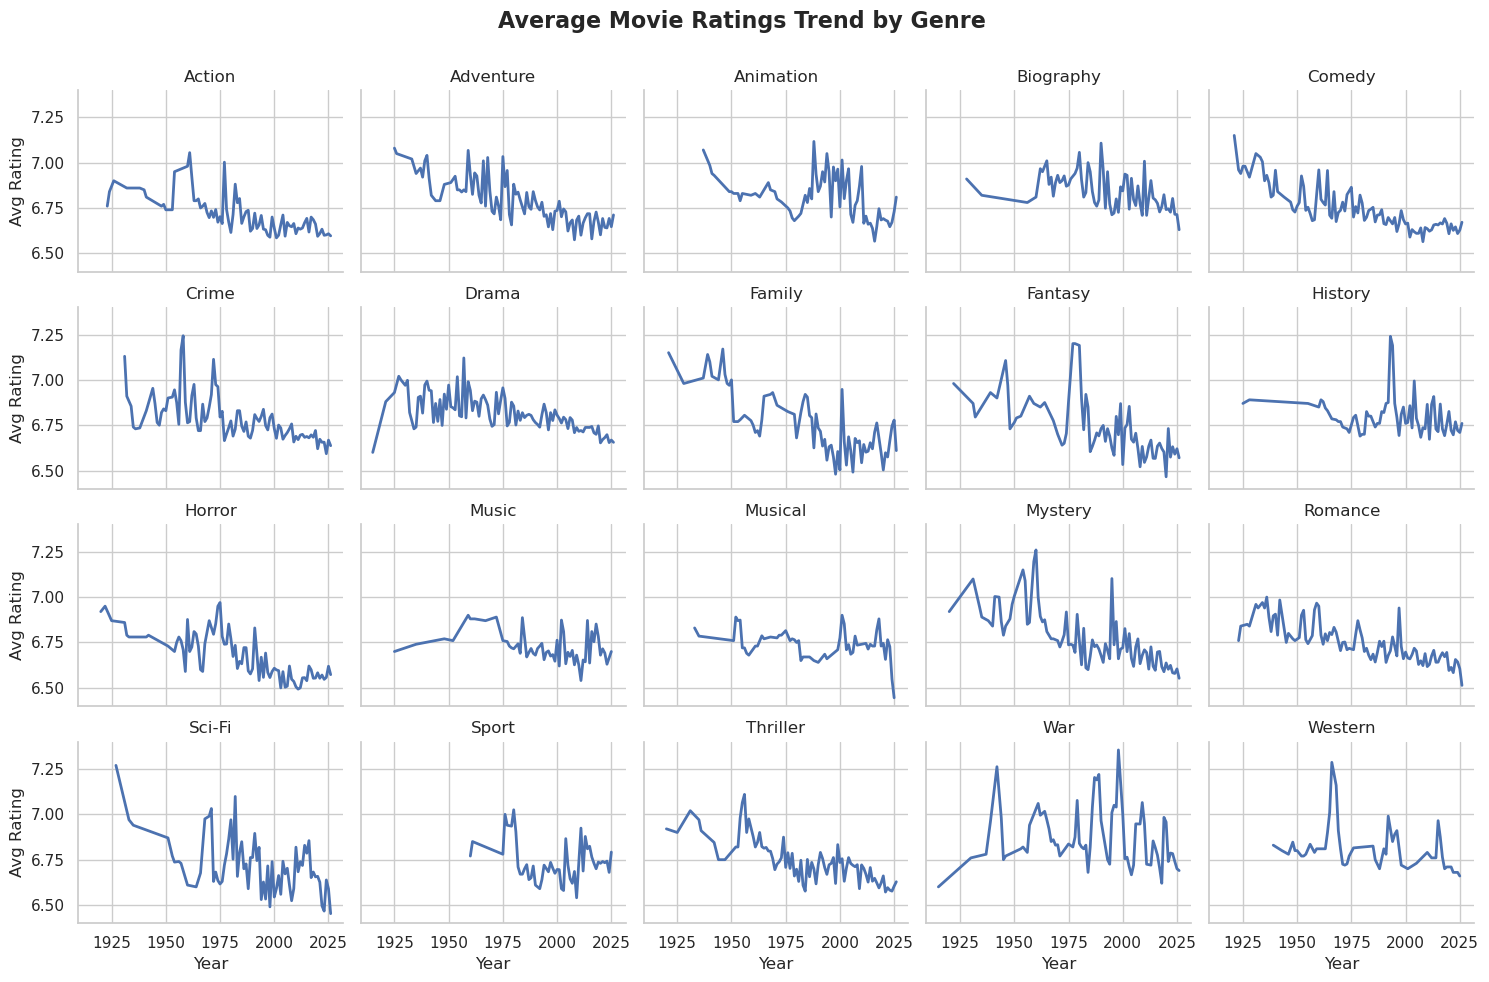

In [15]:
g = sns.relplot(
    data=data,
    x="Year",
    y="smoothed_score",
    col="Genres",  # This splits the data into subplots by genre
    col_wrap=5,  # Sets 5 subplots per row
    kind="line",
    errorbar=None,  # Removes the overlapping shaded areas for a cleaner look
    height=2.5,  # Height of each individual subplot
    aspect=1.2,  # Aspect ratio of each subplot
    linewidth=2,
)

g.set_titles("{col_name}")  # Clean subplot titles (just the Genre name)
g.set_axis_labels("Year", "Avg Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Average Movie Ratings Trend by Genre", fontsize=16, weight="bold")

plt.show()

In [1]:
data

NameError: name 'data' is not defined

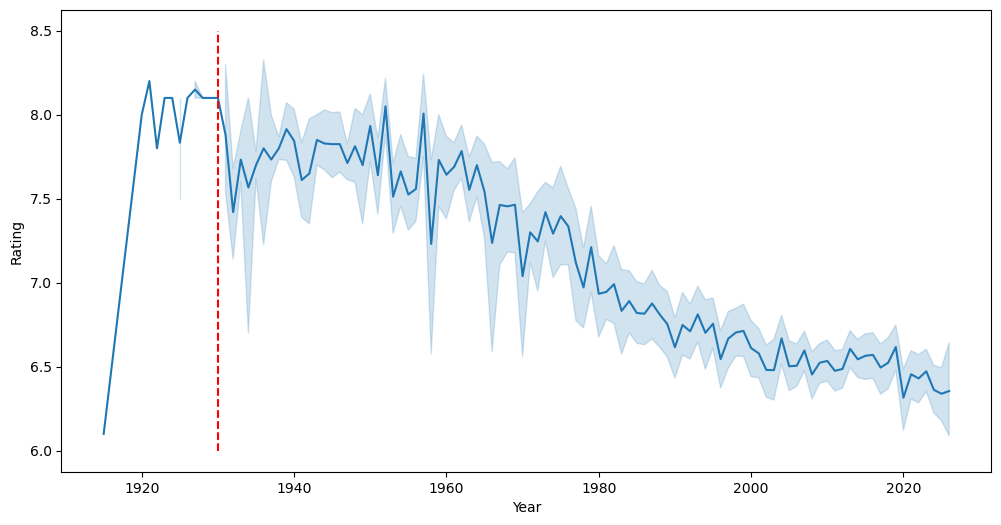

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Year', y='Rating', marker=None)
plt.vlines(x=1930, ymin=6, ymax=8.5, colors='r', linestyles='--', label='1930')

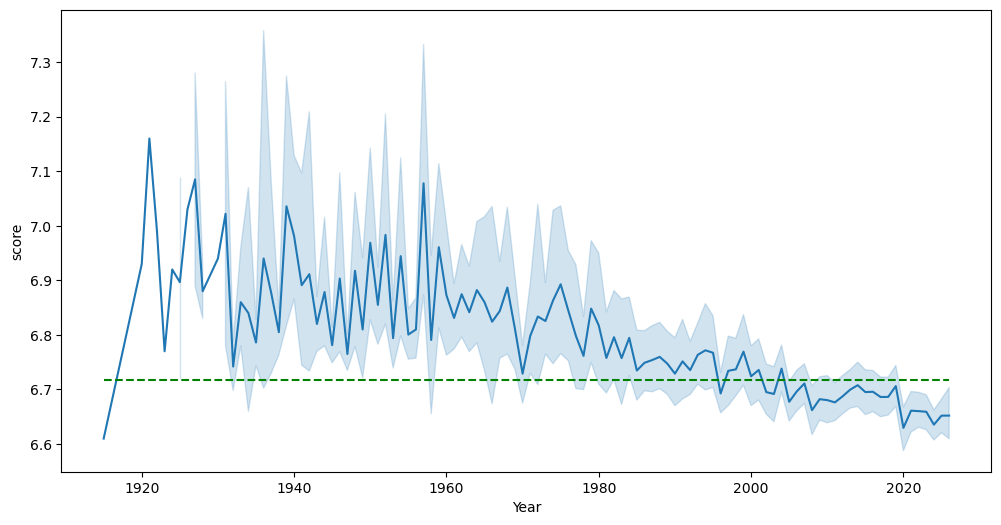

In [31]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Year', y='score', marker=None)
plt.hlines(y=data['score'].mean(), xmin=data['Year'].min(), xmax=data['Year'].max(), colors='g', linestyles='--', label='Mean Score')
# plt.vlines(x=1930, ymin=6, ymax=8.5, colors='r', linestyles='--', label='1930')

<Axes: xlabel='Year', ylabel='Rating'>

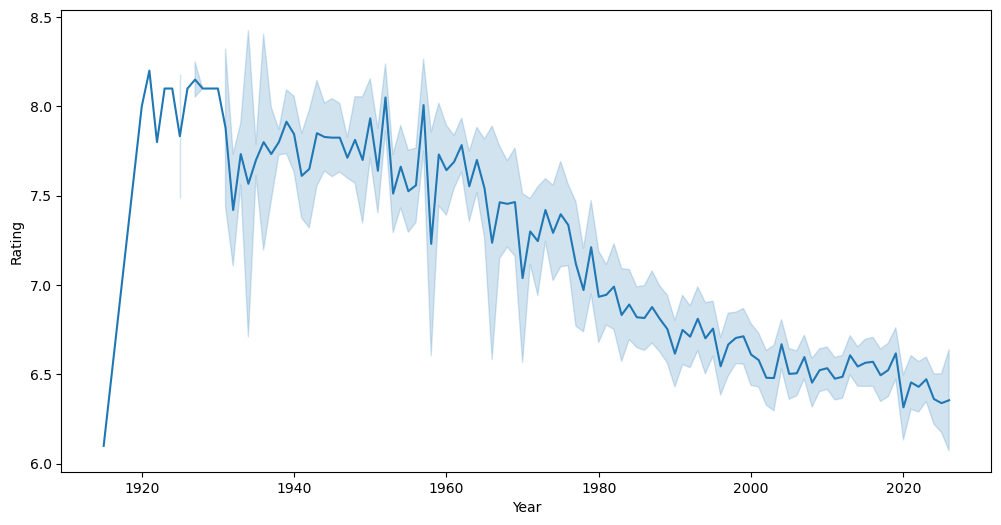

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Year', y='Rating', errorbar=('se', 1.96), marker=None)

In [19]:
data['Votes'].max()

3199370

In [28]:
data.groupby('Year').agg({'Rating': ['mean', 'std', 'count']}).reset_index().rename(columns={'mean': 'Mean Rating', 'std': 'Std Dev', 'count': 'Count'})

Year      Rating                
          Mean Rating   Std Dev Count
0    1921    8.200000  0.000000     3
1    1922    7.800000  0.000000     2
2    1923    8.100000  0.000000     3
3    1924    8.100000  0.000000     3
4    1925    7.875000  0.249285     8
..    ...         ...       ...   ...
100  2022    6.418150  1.033707   573
101  2023    6.475791  0.871015   537
102  2024    6.371371  0.991431   496
103  2025    6.369081  0.982396   359
104  2026    6.390196  0.911153   102

[105 rows x 4 columns]

In [38]:
data[data['Year'] == 1932]

,Title,Year,Genres,Rating,Votes,score,smoothed_score
854,Scarface,1932,Action,7.7,33481,6.75,6.86
854,Scarface,1932,Crime,7.7,33481,6.75,6.91
669,Freaks,1932,Drama,7.8,54881,6.82,6.92
854,Scarface,1932,Drama,7.7,33481,6.75,6.79
1848,Grand Hotel,1932,Drama,7.3,22748,6.69,6.75
1582,Vampyr,1932,Fantasy,7.4,22887,6.70,6.81
3052,The Mummy,1932,Fantasy,6.9,33419,6.67,6.78
669,Freaks,1932,Horror,7.8,54881,6.82,6.83
1582,Vampyr,1932,Horror,7.4,22887,6.70,6.77
3052,The Mummy,1932,Horror,6.9,33419,6.67,6.77


Text(0, 0.5, 'Number of Movies')

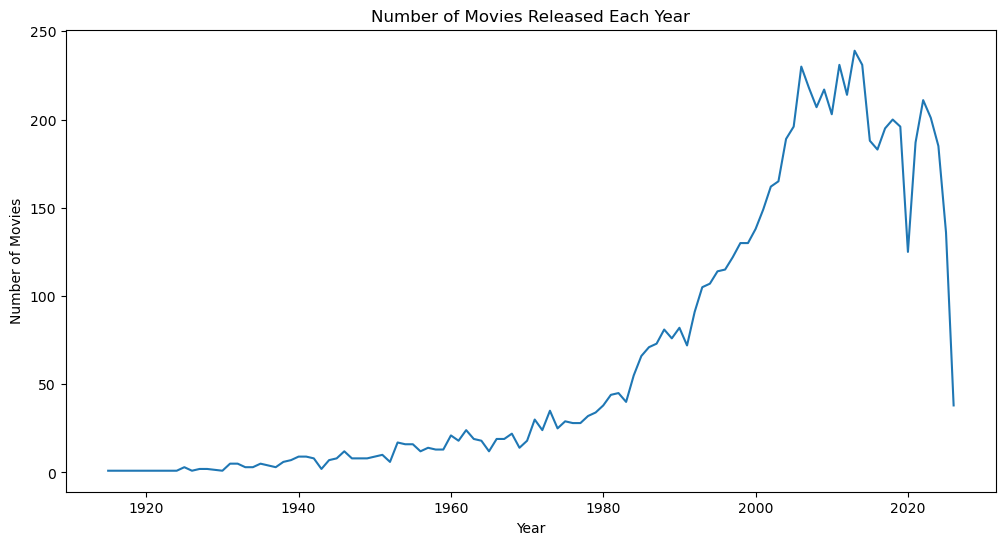

In [18]:
tmp = data['Year'].value_counts().sort_index()
# sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(x=tmp.index, y=tmp.values)
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')